In [2]:
import os
import glob
import json
import gzip
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt

from karhu import load_model
from karhu.common import convert_profiles_si_to_dimensionless, pol2cart
from karhu.utils_input import (
    interpolate_profile,
    scale_model_input,
    descale_minmax)
from karhu.utils_helena import get_f12_data, read_fort20_beta_section, load_from_helena
from karhu.utils_eqdsk import load_from_eqdsk

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

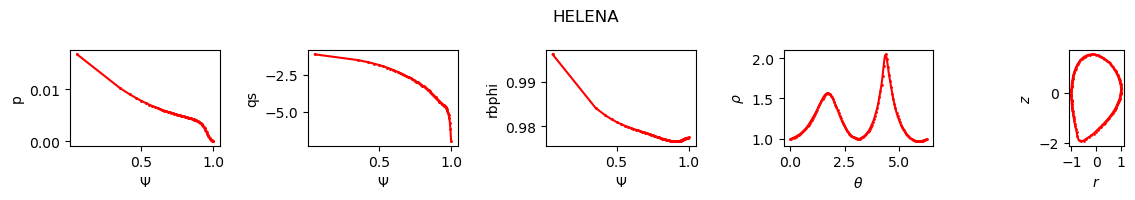

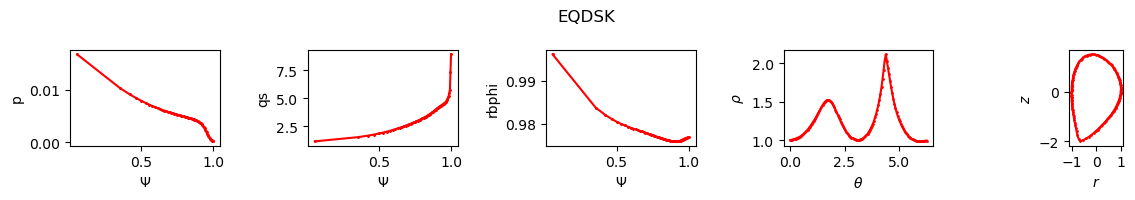

In [3]:
jet_models_directory = os.path.join("..", "model", "jet_2H")  # TODO: add more models
diiid_models_directory = os.path.join("..", "model", "diii-d")  # TODO: add more models

# Load model
model, model_config = load_model(diiid_models_directory)
scaling_params = model_config["scaling_params"]

# EQDSK
eqdskpath = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/tests/data/eqdsk/DIIID_EXAMPLE.eqdsk"
# eqdskpath = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/tests/data/eqdsk/JET.eqdsk"

# HELENA
corresponding_helena = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/tests/data/helena/DIIID_EXAMPLE"
# corresponding_helena = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/tests/data/helena/JET"

# Load model input data
x_eqdsk = load_from_eqdsk(eqdskpath,
    karhu_psin_axis=model_config["karhu_psin_axis"],
    karhu_theta_axis=model_config["karhu_theta_axis"])
x_helena = load_from_helena(corresponding_helena,
    karhu_psin_axis=model_config["karhu_psin_axis"],
    karhu_theta_axis=model_config["karhu_theta_axis"])

# Plot the equilibrium profiles and shapes
fig_x, axs = plt.subplots(1, 5, figsize=(12, 2))
fig_x.suptitle("HELENA")
for i, label in enumerate(['p', 'qs', 'rbphi']):
    axs[i].plot(model_config["karhu_psin_axis"], x_helena[i].flatten(), ".-", c="red", markersize=2, fillstyle="top")
    axs[i].set_xlabel(r"$\Psi$")
    axs[i].set_ylabel(label)
axs[3].plot(model_config["karhu_theta_axis"], x_helena[3].flatten(), ".-", c="red", markersize=2, fillstyle="full")
axs[3].set_xlabel(r"$\theta$")
axs[3].set_ylabel(r"$\rho$")

r, z = pol2cart(x_helena[3].flatten().numpy(), model_config["karhu_theta_axis"])
axs[4].plot(r, z, ".-", c="red", markersize=2, fillstyle="full")
axs[4].set_xlabel(r"$r$")
axs[4].set_ylabel(r"$z$")
axs[4].set_aspect("equal")
plt.tight_layout()
plt.show()

# Plot the equilibrium profiles and shapes
fig_x, axs = plt.subplots(1, 5, figsize=(12, 2))
fig_x.suptitle("EQDSK")
for i, label in enumerate(['p', 'qs', 'rbphi']):
    axs[i].plot(model_config["karhu_psin_axis"], x_eqdsk[i].flatten(), ".-", c="red", markersize=2, fillstyle="top")
    axs[i].set_xlabel(r"$\Psi$")
    axs[i].set_ylabel(label)
axs[3].plot(model_config["karhu_theta_axis"], x_eqdsk[3].flatten(), ".-", c="red", markersize=2, fillstyle="full")
axs[3].set_xlabel(r"$\theta$")
axs[3].set_ylabel(r"$\rho$")

r, z = pol2cart(x_eqdsk[3].flatten().numpy(), model_config["karhu_theta_axis"])
axs[4].plot(r, z, ".-", c="red", markersize=2, fillstyle="full")
axs[4].set_xlabel(r"$r$")
axs[4].set_ylabel(r"$z$")
axs[4].set_aspect("equal")
plt.tight_layout()
plt.show()


In [4]:
# Check similarity
for _x_eq, _x_he in zip(x_eqdsk, x_helena):
    assert torch.allclose(abs(_x_eq), abs(_x_he), rtol=0.25, atol=1.0)

predictions = []
for x in [x_eqdsk, x_helena]:
    x = scale_model_input(x, scaling_params)
    with torch.no_grad():
        y_pred = model(*x)
    y_pred = descale_minmax(y_pred.item(), *scaling_params["growthrate"])
    y_pred = np.max((0.0, y_pred))
    # assert y_pred >= 0.0  # TODO: have some benchmark cases?
    predictions.append(y_pred)
y_pred_eqdsk, y_pred_helena = predictions
print(f"Predicted growth rate EQDSK:  {y_pred_eqdsk:.4f}")
print(f"Predicted growth rate HELENA: {y_pred_helena:.4f}")


Predicted growth rate EQDSK:  0.0152
Predicted growth rate HELENA: 0.2020


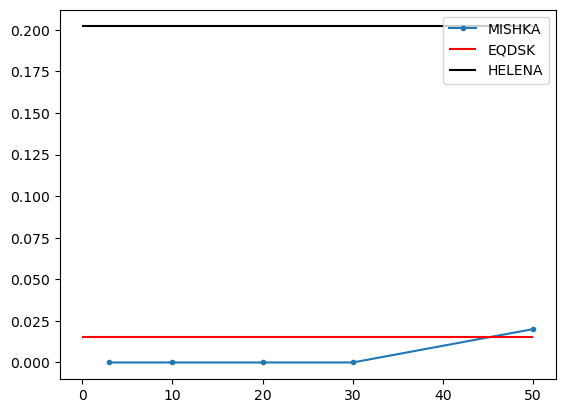

In [5]:
diiid_mishka_growthrates = [
    (-3, -0.7640E-05),
    (-10, -0.3728E-04),
    (-20, -0.3688E-04),
    (-30, -0.6898E-04),
    (-50,  0.4025E-03)
]

# Set negative to zero and take sqrt of positive to get gamma
diiid_mishka_growthrates = np.array([ (-ntor, np.sqrt(np.max((0.0, gamma2)))) for ntor, gamma2 in diiid_mishka_growthrates])

plt.plot(diiid_mishka_growthrates[:, 0], diiid_mishka_growthrates[:, 1], '.-', label="MISHKA")
plt.hlines(y_pred_eqdsk, xmin=0, xmax=50, label="EQDSK", color='red')
plt.hlines(y_pred_helena, xmin=0, xmax=50, label="HELENA", color='black')
plt.legend()

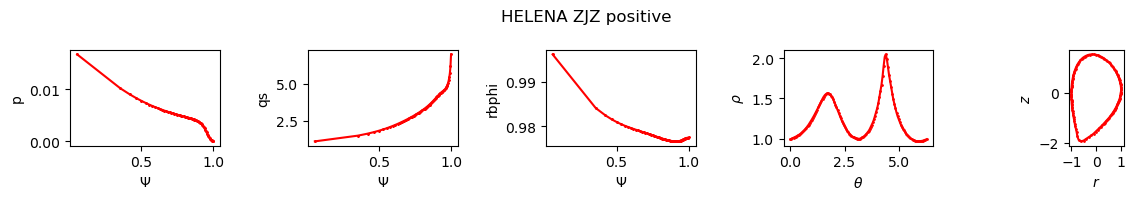

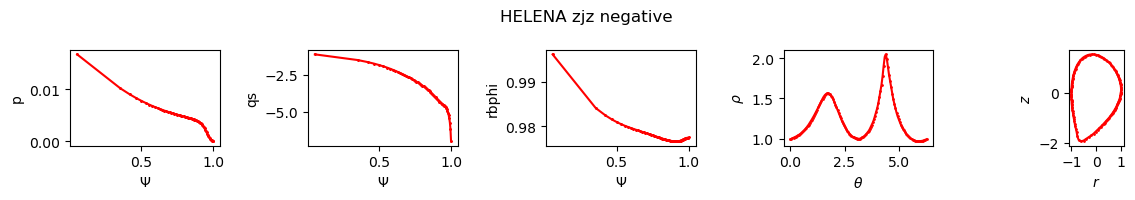

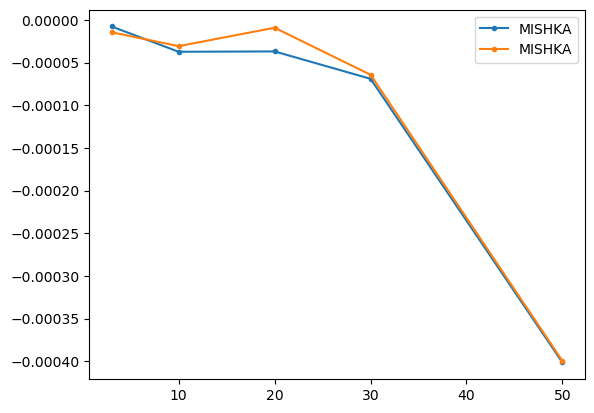

In [11]:

helena_neg = "/scratch/project_2009007/ambrunc/dev_karhu/helena_examples/DIIID_EXAMPLE"
helena_pos = "/scratch/project_2009007/ambrunc/dev_karhu/helena_examples/DIIID_EXAMPLE_posZJZ"
helena_neg_mishka = np.array([
    [3, -0.7640E-05],
    [10, -0.3728E-04],
    [20, -0.3688E-04],
    [30, -0.6898E-04],
    [50,  -0.4014E-03]
])
helena_pos_mishka = np.array([
    [3 , -0.1440E-04],
    [10, -0.3069E-04],
    [20, -0.9117E-05],
    [30,  -0.6422E-04],
    [50,   -0.3996E-03]
])

# Load model input data
x_helena_neg = load_from_helena(helena_neg,
    karhu_psin_axis=model_config["karhu_psin_axis"],
    karhu_theta_axis=model_config["karhu_theta_axis"])
x_helena_pos = load_from_helena(helena_pos,
    karhu_psin_axis=model_config["karhu_psin_axis"],
    karhu_theta_axis=model_config["karhu_theta_axis"])

# Plot the equilibrium profiles and shapes
fig_x, axs = plt.subplots(1, 5, figsize=(12, 2))
fig_x.suptitle("HELENA ZJZ positive")
for i, label in enumerate(['p', 'qs', 'rbphi']):
    axs[i].plot(model_config["karhu_psin_axis"], x_helena_pos[i].flatten(), ".-", c="red", markersize=2, fillstyle="top")
    axs[i].set_xlabel(r"$\Psi$")
    axs[i].set_ylabel(label)
axs[3].plot(model_config["karhu_theta_axis"], x_helena_pos[3].flatten(), ".-", c="red", markersize=2, fillstyle="full")
axs[3].set_xlabel(r"$\theta$")
axs[3].set_ylabel(r"$\rho$")

r, z = pol2cart(x_helena_pos[3].flatten().numpy(), model_config["karhu_theta_axis"])
axs[4].plot(r, z, ".-", c="red", markersize=2, fillstyle="full")
axs[4].set_xlabel(r"$r$")
axs[4].set_ylabel(r"$z$")
axs[4].set_aspect("equal")
plt.tight_layout()
plt.show()

# Plot the equilibrium profiles and shapes
fig_x, axs = plt.subplots(1, 5, figsize=(12, 2))
fig_x.suptitle("HELENA zjz negative")
for i, label in enumerate(['p', 'qs', 'rbphi']):
    axs[i].plot(model_config["karhu_psin_axis"], x_helena_neg[i].flatten(), ".-", c="red", markersize=2, fillstyle="top")
    axs[i].set_xlabel(r"$\Psi$")
    axs[i].set_ylabel(label)
axs[3].plot(model_config["karhu_theta_axis"], x_helena_neg[3].flatten(), ".-", c="red", markersize=2, fillstyle="full")
axs[3].set_xlabel(r"$\theta$")
axs[3].set_ylabel(r"$\rho$")

r, z = pol2cart(x_helena_neg[3].flatten().numpy(), model_config["karhu_theta_axis"])
axs[4].plot(r, z, ".-", c="red", markersize=2, fillstyle="full")
axs[4].set_xlabel(r"$r$")
axs[4].set_ylabel(r"$z$")
axs[4].set_aspect("equal")
plt.tight_layout()
plt.show()

plt.plot(helena_neg_mishka[:, 0], helena_neg_mishka[:, 1], '.-', label="MISHKA")
plt.plot(helena_pos_mishka[:, 0], helena_pos_mishka[:, 1], '.-', label="MISHKA")
# plt.hlines(y_pred_eqdsk, xmin=0, xmax=50, label="EQDSK")
# plt.hlines(y_pred_helena, xmin=0, xmax=50, label="HELENA")
plt.legend()

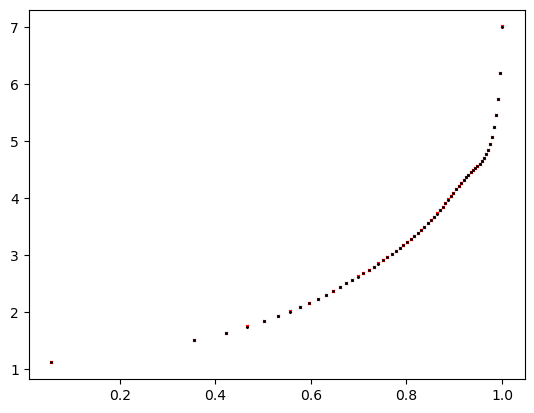

In [ ]:
plt.plot(model_config["karhu_psin_axis"], x_helena_pos[1].flatten(), "x", c="red", markersize=2, fillstyle="top")
plt.plot(model_config["karhu_psin_axis"], abs(x_helena_neg[1].flatten()), ".", c="black", markersize=2, fillstyle="top")